In [ ]:
  !pip install transformers datasets scikit-learn pandas -q

In [ ]:
from datasets import load_dataset

dataset     = load_dataset('ag_news', split='test[:200]')
articles    = list(dataset['text'])
true_labels = list(dataset['label'])

CATEGORIES = ['World News', 'Sports', 'Business', 'Science and Technology']

print(f"Total articles loaded : {len(articles)}")
print(f"\nSample article (first 300 chars):\n{articles[0][:300]}")
print(f"\nTrue label            : {CATEGORIES[true_labels[0]]}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Total articles loaded : 200

Sample article (first 300 chars):
Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.

True label            : Business


In [ ]:
import torch
device = 0 if torch.cuda.is_available() else -1
print("Device:", device)
batch_size = 16 if torch.cuda.is_available() else 1
print("Batch size:", batch_size)


Device: 0
Batch size: 16


In [ ]:
from transformers import pipeline

model_distilbert = pipeline('zero-shot-classification',
                             model='typeform/distilbert-base-uncased-mnli',
                             device=device)
print("DistilBERT loaded")

config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

DistilBERT loaded


In [ ]:
model_roberta = pipeline('zero-shot-classification',
                          model='cross-encoder/nli-roberta-base',
                          device=device)
print("RoBERTa loaded")


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

RoBERTa loaded


In [ ]:
model_bart = pipeline('zero-shot-classification',
                       model='facebook/bart-large-mnli',
                       device=0)
print("BART loaded")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BART loaded


In [ ]:
models = {
    'DistilBERT' : model_distilbert,
    'RoBERTa'    : model_roberta,
    'BART-large' : model_bart,
}

print("Models ready:", list(models.keys()))

Models ready: ['DistilBERT', 'RoBERTa', 'BART-large']


In [ ]:
labels_short = [
    'World',
    'Sports',
    'Business',
    'Science and Technology'
]
print("Short labels:", labels_short)

Short labels: ['World', 'Sports', 'Business', 'Science and Technology']


In [ ]:
labels_descriptive = [
    'World news, politics, and global events',
    'Sports, athletics, teams, and competitions',
    'Business, economy, finance, and markets',
    'Science, technology, AI, and innovation'
]
print("Descriptive labels ready")

Descriptive labels ready


In [ ]:
labels_hypothesis = [
    'This article is about world news or politics',
    'This article is about sports or athletics',
    'This article is about business or economy',
    'This article is about science or technology'
]
print("Hypothesis labels ready")

Hypothesis labels ready


In [ ]:
prompts = {
    'Short'       : labels_short,
    'Descriptive' : labels_descriptive,
    'Hypothesis'  : labels_hypothesis,
}
print("Prompts ready:", list(prompts.keys()))


Prompts ready: ['Short', 'Descriptive', 'Hypothesis']


In [ ]:
result = model_distilbert(articles[0], candidate_labels=labels_short)
print(result)

{'sequence': "Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.", 'labels': ['Business', 'World', 'Science and Technology', 'Sports'], 'scores': [0.3435410261154175, 0.2998654544353485, 0.23315328359603882, 0.12344023585319519]}


In [ ]:
print("Predicted :", result['labels'][0])
print("Confidence:", round(result['scores'][0], 3))
print("True label:", CATEGORIES[true_labels[0]])

Predicted : Business
Confidence: 0.344
True label: Business


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import time

In [ ]:
start = time.time()

outputs = model_distilbert(
    articles,
    candidate_labels=labels_short,
    batch_size=batch_size,
    truncation=True,
    max_length=512
)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")

Done in 2.3 seconds


In [ ]:
preds = [labels_short.index(out['labels'][0]) for out in outputs]
print("First 10 predictions:", preds[:10])
print("First 10 true labels:", true_labels[:10])

First 10 predictions: [2, 3, 3, 0, 3, 0, 0, 3, 0, 0]
First 10 true labels: [2, 3, 3, 3, 3, 3, 3, 3, 3, 3]


In [ ]:
acc = accuracy_score(true_labels, preds)
print(f"Accuracy: {acc:.2%}")

Accuracy: 56.50%


In [ ]:
f1 = f1_score(true_labels, preds, average='weighted')
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.555


In [ ]:
scores = [out['scores'][0] for out in outputs]
correct_scores = [s for s, p, t in zip(scores, preds, true_labels) if p == t]
wrong_scores = [s for s, p, t in zip(scores, preds, true_labels) if p != t]
avg_correct = sum(correct_scores) / len(correct_scores)
avg_wrong = sum(wrong_scores) / len(wrong_scores)

print(f"Confidence when RIGHT : {avg_correct:.2f}")
print(f"Confidence when WRONG : {avg_wrong:.2f}")
print(f"Gap : {avg_correct - avg_wrong:.2f}")

Confidence when RIGHT : 0.43
Confidence when WRONG : 0.35
Gap : 0.08


In [ ]:
shown = 0
for article, true, pred in zip(articles, true_labels, preds):
    if true != pred and shown < 3:
        print(f"TRUE     : {CATEGORIES[true]}")
        print(f"PREDICTED: {CATEGORIES[pred]}")
        print(f"TEXT     : {article[:200]}\n")
        shown += 1

TRUE     : Science and Technology
PREDICTED: World News
TEXT     : Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day w

TRUE     : Science and Technology
PREDICTED: World News
TEXT     : Open Letter Against British Copyright Indoctrination in Schools The British Department for Education and Skills (DfES) recently launched a "Music Manifesto" campaign, with the ostensible intention of 

TRUE     : Science and Technology
PREDICTED: World News
TEXT     : Loosing the War on Terrorism \\"Sven Jaschan, self-confessed author of the Netsky and Sasser viruses, is\responsible for 70 percent of virus infections in 2004, according to a six-month\virus roundup 



In [ ]:
results = []
print("Results list ready")

Results list ready


In [ ]:
for model_name, clf in models.items():
    for prompt_name, label_names in prompts.items():
        print(f"Running {model_name} + {prompt_name}...")

Running DistilBERT + Short...
Running DistilBERT + Descriptive...
Running DistilBERT + Hypothesis...
Running RoBERTa + Short...
Running RoBERTa + Descriptive...
Running RoBERTa + Hypothesis...
Running BART-large + Short...
Running BART-large + Descriptive...
Running BART-large + Hypothesis...


In [ ]:
for model_name, clf in models.items():
    for prompt_name, label_names in prompts.items():
        print(f"\nRunning {model_name} + {prompt_name}...")

        start   = time.time()
        outputs = clf(articles, candidate_labels=label_names,
                      batch_size=batch_size, truncation=True, max_length=512)
        elapsed = time.time() - start

        preds  = [label_names.index(o['labels'][0]) for o in outputs]
        scores = [o['scores'][0] for o in outputs]

        print(f"Done in {elapsed:.1f}s")


Running DistilBERT + Short...
Done in 2.3s

Running DistilBERT + Descriptive...
Done in 2.3s

Running DistilBERT + Hypothesis...
Done in 2.3s

Running RoBERTa + Short...
Done in 4.2s

Running RoBERTa + Descriptive...
Done in 4.5s

Running RoBERTa + Hypothesis...
Done in 4.5s

Running BART-large + Short...
Done in 16.0s

Running BART-large + Descriptive...
Done in 17.6s

Running BART-large + Hypothesis...
Done in 19.3s


In [ ]:
for model_name, clf in models.items():
    for prompt_name, label_names in prompts.items():
        print(f"\nRunning {model_name} + {prompt_name}...")

        start   = time.time()
        outputs = clf(articles, candidate_labels=label_names,
                      batch_size=batch_size, truncation=True, max_length=512)
        elapsed = time.time() - start

        preds  = [label_names.index(o['labels'][0]) for o in outputs]
        scores = [o['scores'][0] for o in outputs]

        acc = accuracy_score(true_labels, preds)
        f1  = f1_score(true_labels, preds, average='weighted')

        c = [s for s,p,t in zip(scores,preds,true_labels) if p == t]
        w = [s for s,p,t in zip(scores,preds,true_labels) if p != t]
        gap = (sum(c)/len(c)) - (sum(w)/len(w))

        print(f"Accuracy: {acc:.2%}  |  F1: {f1:.3f}  |  Gap: {gap:.2f}  |  Time: {elapsed/200:.2f}s/article")


Running DistilBERT + Short...
Accuracy: 56.50%  |  F1: 0.555  |  Gap: 0.08  |  Time: 0.01s/article

Running DistilBERT + Descriptive...
Accuracy: 51.50%  |  F1: 0.471  |  Gap: 0.04  |  Time: 0.01s/article

Running DistilBERT + Hypothesis...
Accuracy: 71.50%  |  F1: 0.723  |  Gap: 0.06  |  Time: 0.01s/article

Running RoBERTa + Short...
Accuracy: 63.00%  |  F1: 0.588  |  Gap: 0.14  |  Time: 0.02s/article

Running RoBERTa + Descriptive...
Accuracy: 72.00%  |  F1: 0.701  |  Gap: 0.21  |  Time: 0.02s/article

Running RoBERTa + Hypothesis...
Accuracy: 77.50%  |  F1: 0.781  |  Gap: 0.19  |  Time: 0.02s/article

Running BART-large + Short...
Accuracy: 66.50%  |  F1: 0.631  |  Gap: 0.12  |  Time: 0.09s/article

Running BART-large + Descriptive...
Accuracy: 76.00%  |  F1: 0.744  |  Gap: 0.13  |  Time: 0.09s/article

Running BART-large + Hypothesis...
Accuracy: 77.00%  |  F1: 0.784  |  Gap: 0.12  |  Time: 0.09s/article


In [ ]:
for model_name, clf in models.items():
    for prompt_name, label_names in prompts.items():
        print(f"\nRunning {model_name} + {prompt_name}...")

        start   = time.time()
        outputs = clf(articles, candidate_labels=label_names,
                      batch_size=batch_size, truncation=True, max_length=512)
        elapsed = time.time() - start

        preds  = [label_names.index(o['labels'][0]) for o in outputs]
        scores = [o['scores'][0] for o in outputs]

        acc = accuracy_score(true_labels, preds)
        f1  = f1_score(true_labels, preds, average='weighted')

        c = [s for s,p,t in zip(scores,preds,true_labels) if p == t]
        w = [s for s,p,t in zip(scores,preds,true_labels) if p != t]
        gap = (sum(c)/len(c)) - (sum(w)/len(w))

        results.append({
            'Model'      : model_name,
            'Prompt'     : prompt_name,
            'Accuracy'   : f'{acc:.2%}',
            'F1'         : f'{f1:.3f}',
            'Conf Gap'   : f'{gap:.2f}',
            'Sec/Article': f'{elapsed/200:.2f}s'
        })

        print(f"Accuracy: {acc:.2%}  |  F1: {f1:.3f}  |  Gap: {gap:.2f}  |  Time: {elapsed/200:.2f}s/article")


Running DistilBERT + Short...
Accuracy: 56.50%  |  F1: 0.555  |  Gap: 0.08  |  Time: 0.01s/article

Running DistilBERT + Descriptive...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy: 51.50%  |  F1: 0.471  |  Gap: 0.04  |  Time: 0.01s/article

Running DistilBERT + Hypothesis...
Accuracy: 71.50%  |  F1: 0.723  |  Gap: 0.06  |  Time: 0.01s/article

Running RoBERTa + Short...
Accuracy: 63.00%  |  F1: 0.588  |  Gap: 0.14  |  Time: 0.02s/article

Running RoBERTa + Descriptive...
Accuracy: 72.00%  |  F1: 0.701  |  Gap: 0.21  |  Time: 0.02s/article

Running RoBERTa + Hypothesis...
Accuracy: 77.50%  |  F1: 0.781  |  Gap: 0.19  |  Time: 0.02s/article

Running BART-large + Short...
Accuracy: 66.50%  |  F1: 0.631  |  Gap: 0.12  |  Time: 0.08s/article

Running BART-large + Descriptive...
Accuracy: 76.00%  |  F1: 0.744  |  Gap: 0.13  |  Time: 0.09s/article

Running BART-large + Hypothesis...
Accuracy: 77.00%  |  F1: 0.784  |  Gap: 0.12  |  Time: 0.09s/article


In [ ]:
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))

     Model      Prompt Accuracy    F1 Conf Gap Sec/Article
DistilBERT       Short   56.50% 0.555     0.08       0.01s
DistilBERT Descriptive   51.50% 0.471     0.04       0.01s
DistilBERT  Hypothesis   71.50% 0.723     0.06       0.01s
   RoBERTa       Short   63.00% 0.588     0.14       0.02s
   RoBERTa Descriptive   72.00% 0.701     0.21       0.02s
   RoBERTa  Hypothesis   77.50% 0.781     0.19       0.02s
BART-large       Short   66.50% 0.631     0.12       0.08s
BART-large Descriptive   76.00% 0.744     0.13       0.09s
BART-large  Hypothesis   77.00% 0.784     0.12       0.09s


In [ ]:
df.to_csv('results.csv', index=False)
print("Saved to results.csv")

Saved to results.csv


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

In [ ]:
best_outputs = model_roberta(
    articles,
    candidate_labels=labels_hypothesis,
    batch_size=batch_size,
    truncation=True,
    max_length=512
)

best_preds = [labels_hypothesis.index(o['labels'][0]) for o in best_outputs]
print("Predictions ready:", len(best_preds))

Predictions ready: 200


In [ ]:
cm = confusion_matrix(true_labels, best_preds)

df_cm = pd.DataFrame(cm,
    index  =['Actual World', 'Actual Sports', 'Actual Business', 'Actual Sci/Tech'],
    columns=['Pred World',   'Pred Sports',   'Pred Business',   'Pred Sci/Tech']
)

print(df_cm)

                 Pred World  Pred Sports  Pred Business  Pred Sci/Tech
Actual World             42            3              9              7
Actual Sports             1           52              0              0
Actual Business           2            0             22              5
Actual Sci/Tech           3            0             15             39


In [ ]:
print(classification_report(
    true_labels,
    best_preds,
    target_names=['World News', 'Sports', 'Business', 'Sci/Tech']
))

              precision    recall  f1-score   support

  World News       0.88      0.69      0.77        61
      Sports       0.95      0.98      0.96        53
    Business       0.48      0.76      0.59        29
    Sci/Tech       0.76      0.68      0.72        57

    accuracy                           0.78       200
   macro avg       0.77      0.78      0.76       200
weighted avg       0.80      0.78      0.78       200



In [ ]:
shown = 0
for article, true, pred in zip(articles, true_labels, best_preds):
    if true != pred and shown < 5:
        print(f"TRUE     : {CATEGORIES[true]}")
        print(f"PREDICTED: {CATEGORIES[pred]}")
        print(f"TEXT     : {article[:250]}\n")
        shown += 1

TRUE     : Science and Technology
PREDICTED: World News
TEXT     : Open Letter Against British Copyright Indoctrination in Schools The British Department for Education and Skills (DfES) recently launched a "Music Manifesto" campaign, with the ostensible intention of educating the next generation of British musicians

TRUE     : Science and Technology
PREDICTED: Business
TEXT     : E-mail scam targets police chief Wiltshire Police warns about "phishing" after its fraud squad chief was targeted.

TRUE     : Science and Technology
PREDICTED: Business
TEXT     : Dutch Retailer Beats Apple to Local Download Market  AMSTERDAM (Reuters) - Free Record Shop, a Dutch music  retail chain, beat Apple Computer Inc. to market on Tuesday  with the launch of a new download service in Europe's latest  battleground for di

TRUE     : Science and Technology
PREDICTED: Business
TEXT     : IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount sinc

In [ ]:
import matplotlib.pyplot as plt

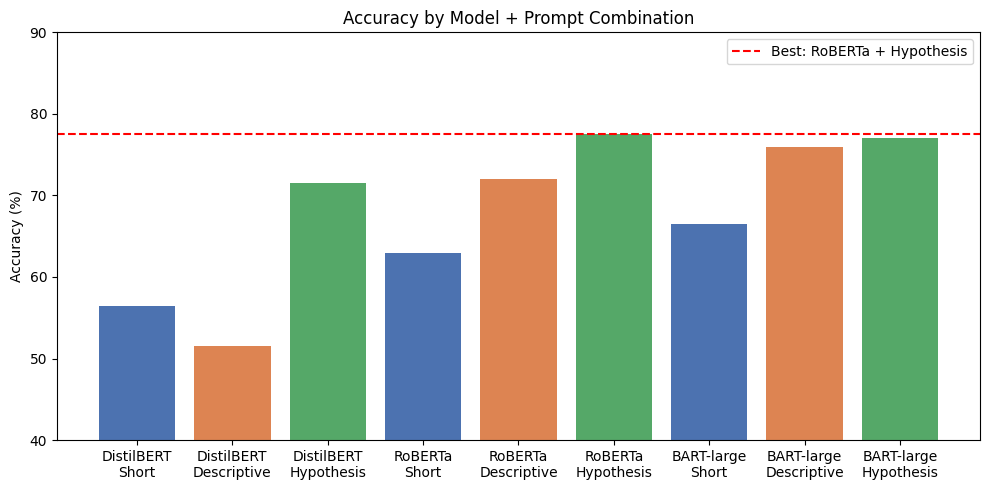

Saved as accuracy_chart.png


In [ ]:
models_list  = ['DistilBERT', 'DistilBERT', 'DistilBERT',
                 'RoBERTa',    'RoBERTa',    'RoBERTa',
                 'BART-large', 'BART-large', 'BART-large']

prompts_list = ['Short', 'Descriptive', 'Hypothesis'] * 3

accuracy_list = [56.5, 51.5, 71.5,
                 63.0, 72.0, 77.5,
                 66.5, 76.0, 77.0]

colors = ['#4C72B0', '#DD8452', '#55A868'] * 3

plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f"{m}\n{p}" for m, p in zip(models_list, prompts_list)],
    accuracy_list,
    color=colors
)
plt.ylim(40, 90)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy by Model + Prompt Combination")
plt.axhline(y=77.5, color='red', linestyle='--', label='Best: RoBERTa + Hypothesis')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_chart.png', dpi=150)
plt.show()
print("Saved as accuracy_chart.png")

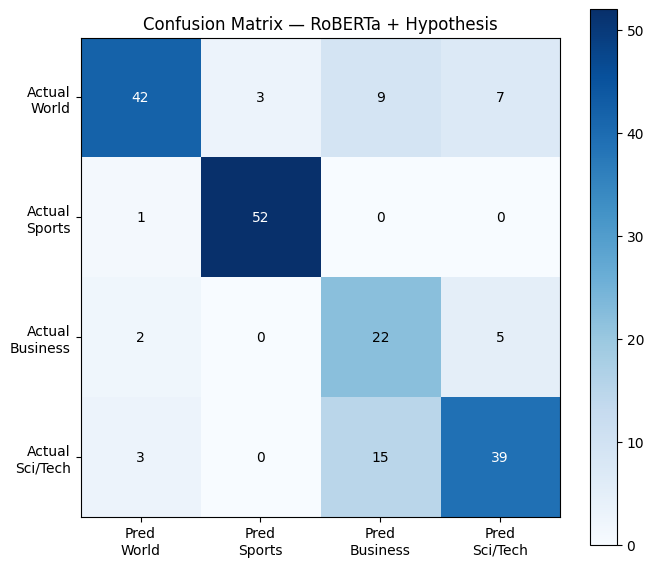

Saved as confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm_data = [
    [42,  3,  9,  7],
    [ 1, 52,  0,  0],
    [ 2,  0, 22,  5],
    [ 3,  0, 15, 39]
]

labels = ['World', 'Sports', 'Business', 'Sci/Tech']
cm_array = np.array(cm_data)

plt.figure(figsize=(7, 6))
plt.imshow(cm_array, cmap='Blues')
plt.colorbar()
plt.xticks(range(4), ['Pred\nWorld', 'Pred\nSports', 'Pred\nBusiness', 'Pred\nSci/Tech'])
plt.yticks(range(4), ['Actual\nWorld', 'Actual\nSports', 'Actual\nBusiness', 'Actual\nSci/Tech'])

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm_array[i, j],
                 ha='center', va='center',
                 color='white' if cm_array[i, j] > 30 else 'black')

plt.title("Confusion Matrix — RoBERTa + Hypothesis")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved as confusion_matrix.png")

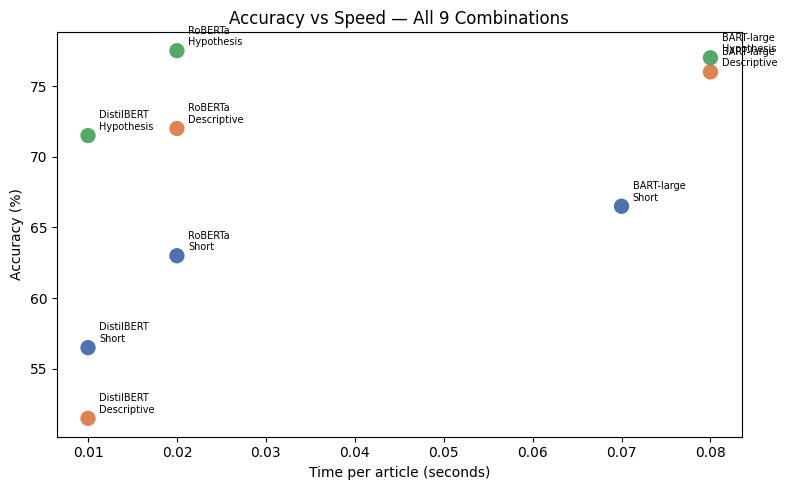

Saved as speed_vs_accuracy.png


In [ ]:
speed  = [0.01, 0.01, 0.01, 0.02, 0.02, 0.02, 0.07, 0.08, 0.08]
acc    = [56.5, 51.5, 71.5, 63.0, 72.0, 77.5, 66.5, 76.0, 77.0]
labels_plot = [f"{m}\n{p}" for m, p in zip(models_list, prompts_list)]

plt.figure(figsize=(8, 5))
plt.scatter(speed, acc, s=100, color=colors)

for i, label in enumerate(labels_plot):
    plt.annotate(label, (speed[i], acc[i]),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=7)

plt.xlabel("Time per article (seconds)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Speed — All 9 Combinations")
plt.tight_layout()
plt.savefig('speed_vs_accuracy.png', dpi=150)
plt.show()
print("Saved as speed_vs_accuracy.png")